# **EDA and Visualizations**

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import warnings
warnings.filterwarnings('ignore')

### Importing Dataset

In [2]:
merged_df = pd.read_csv(
    '../data/merged/merged_dataset.csv'
)

### Data Conversion

In [3]:
merged_df['sales_date'] = pd.to_datetime(
    merged_df['sales_date'],
    errors='coerce'
)

### Color Palette

In [4]:
PRIMARY_COLOR = '#1F3C88'
SECONDARY_COLOR = '#5893D4'
ACCENT_COLOR = '#F49D37'
SUCCESS_COLOR = '#4CAF50'
DANGER_COLOR = '#D7263D'
BACKGROUND_COLOR = '#F5F7FA'

### Revenue By Category

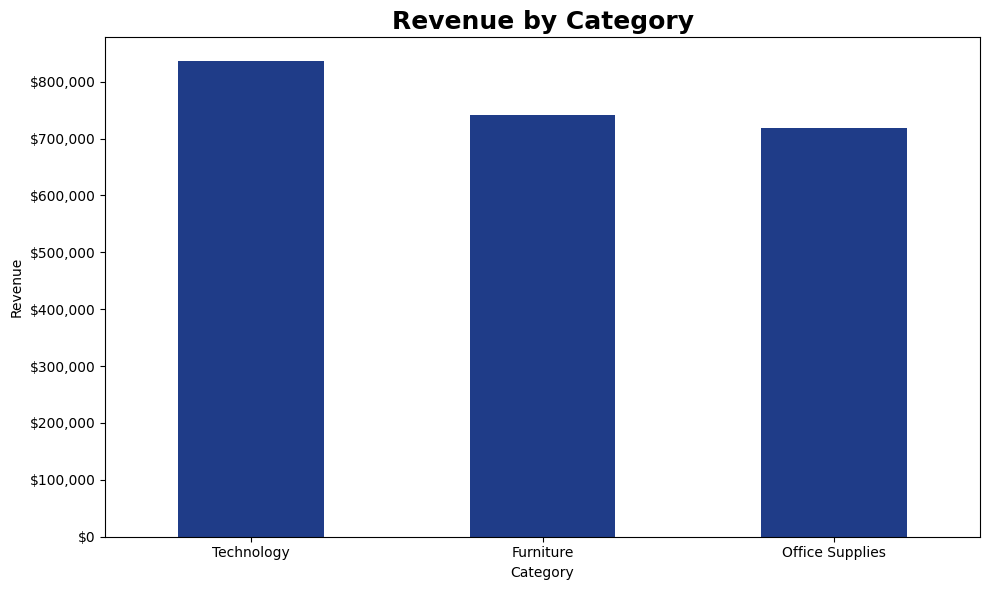

In [5]:
category_revenue = (
    merged_df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 6))
category_revenue.plot(
    kind='bar',
    color=PRIMARY_COLOR
)
plt.title(
    'Revenue by Category',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    '../visuals/charts/revenue_by_category.png',
    dpi=300
)
plt.show()

### Profit By Region

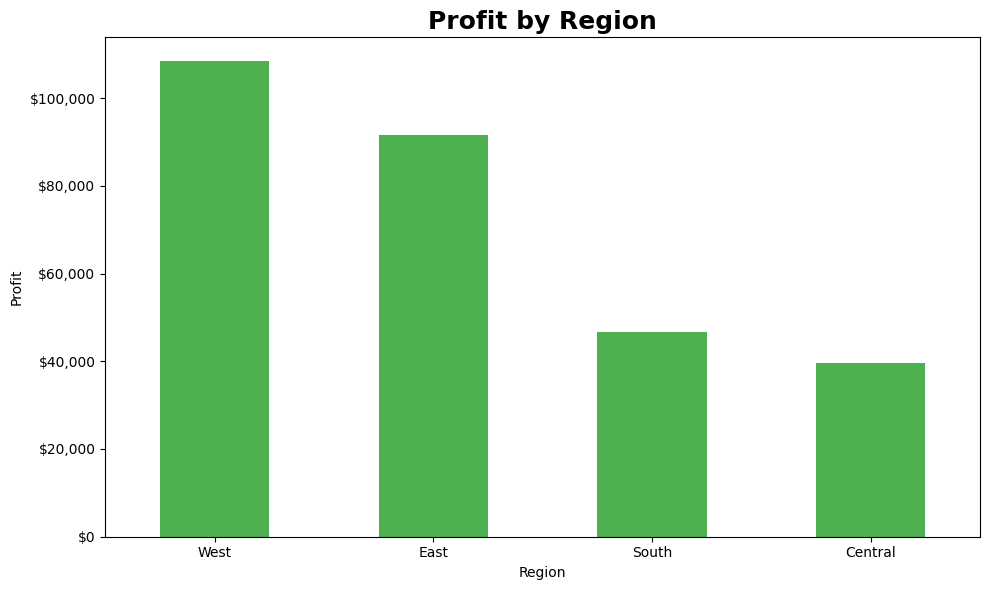

In [6]:
region_profit = (
    merged_df.groupby('region')['profit']
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 6))
region_profit.plot(
    kind='bar',
    color=SUCCESS_COLOR
)
plt.title(
    'Profit by Region',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Region')
plt.ylabel('Profit')
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    '../visuals/charts/profit_by_region.png',
    dpi=300
)
plt.show()

### Discount Vs Revenue

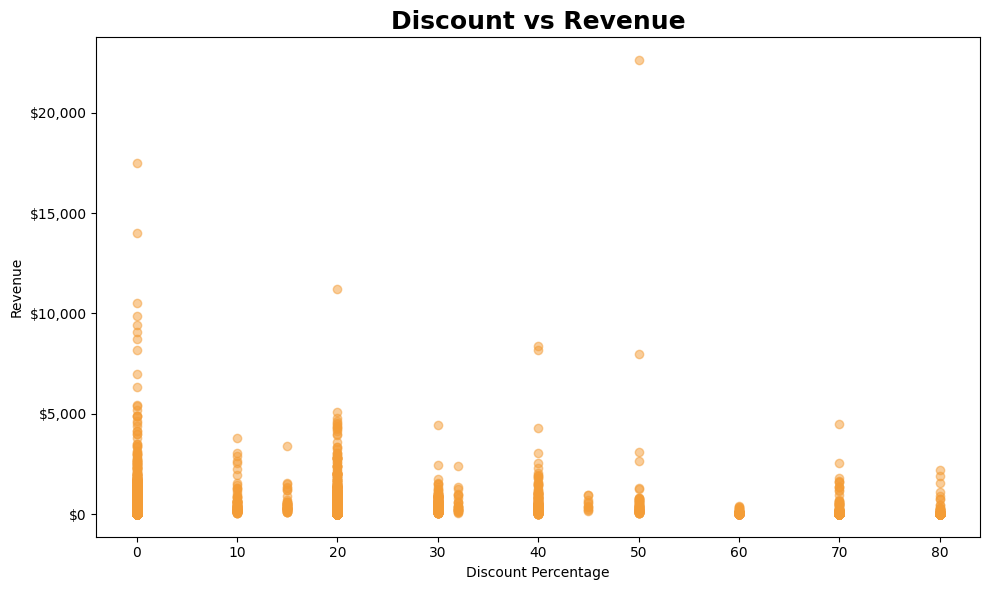

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(
    merged_df['discount_percentage'],
    merged_df['revenue'],
    alpha=0.5,
    color=ACCENT_COLOR
)
plt.title(
    'Discount vs Revenue',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Discount Percentage')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)
plt.tight_layout()
plt.savefig(
    '../visuals/charts/discount_vs_revenue.png',
    dpi=300
)
plt.show()

### Price Vs Unit Sold

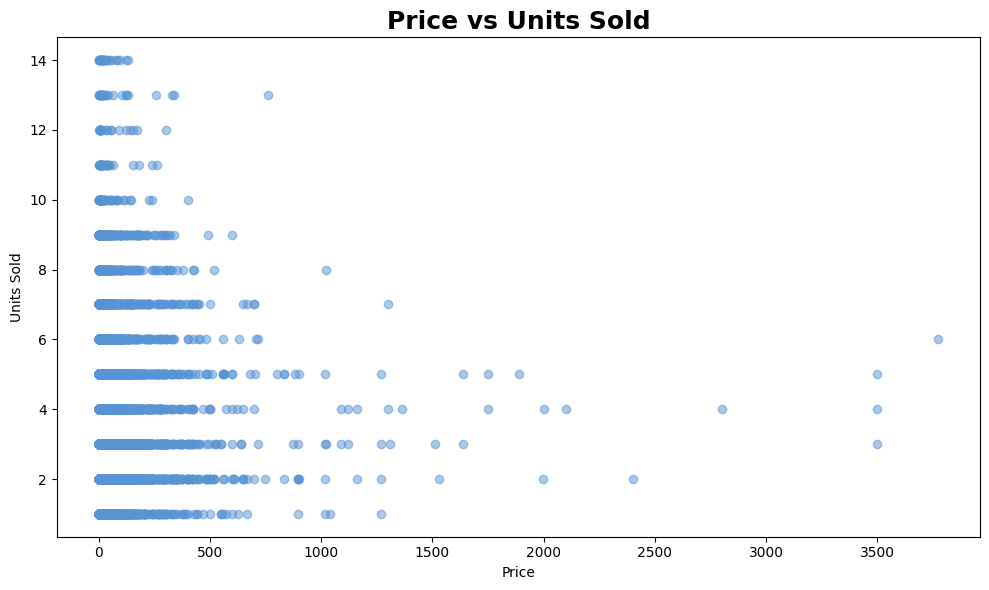

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(
    merged_df['price'],
    merged_df['units_sold'],
    alpha=0.5,
    color=SECONDARY_COLOR
)
plt.title(
    'Price vs Units Sold',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Price')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig(
    '../visuals/charts/price_vs_units_sold.png',
    dpi=300
)
plt.show()

### Monthly Revenue Trend

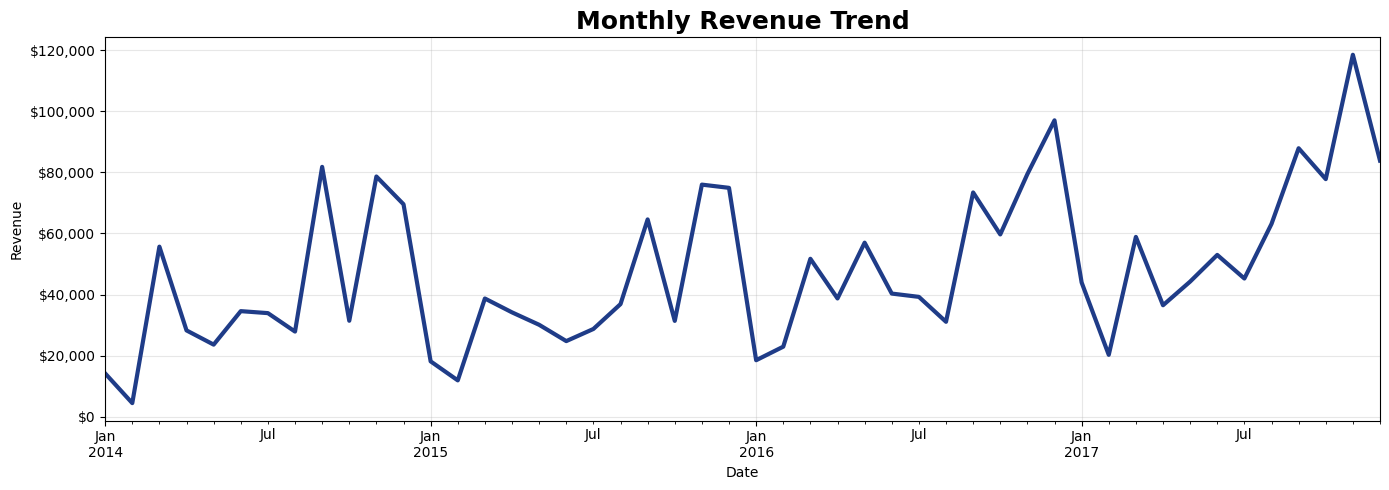

In [13]:
monthly_revenue = (
    merged_df
    .set_index('sales_date')
    .resample('M')['revenue']
    .sum()
)
plt.figure(figsize=(14, 5))
monthly_revenue.plot(
    color=PRIMARY_COLOR,
    linewidth=3
)
plt.title(
    'Monthly Revenue Trend',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    '../visuals/charts/monthly_revenue_trend.png',
    dpi=300
)
plt.show()

### Top 10 Revenue Products

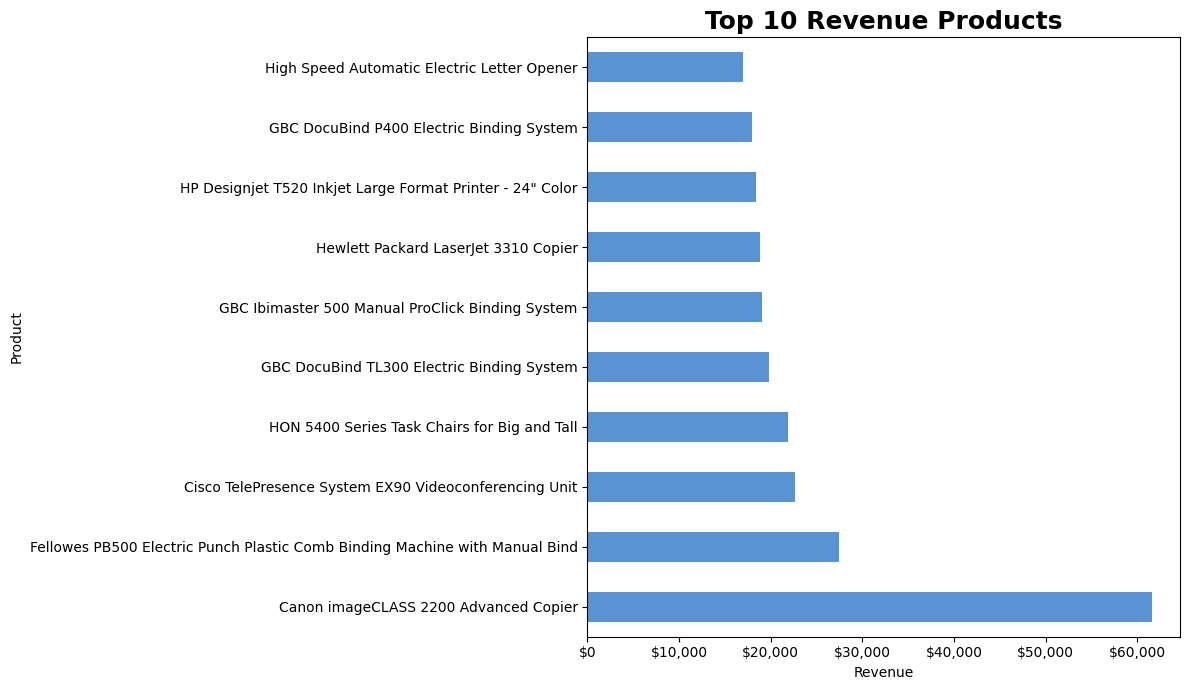

In [14]:
top_products = (
    merged_df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12, 7))
top_products.plot(
    kind='barh',
    color=SECONDARY_COLOR
)
plt.title(
    'Top 10 Revenue Products',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.gca().xaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)
plt.tight_layout()
plt.savefig(
    '../visuals/charts/top_10_products.png',
    dpi=300
)
plt.show()

### Competitor Price Gap by Category

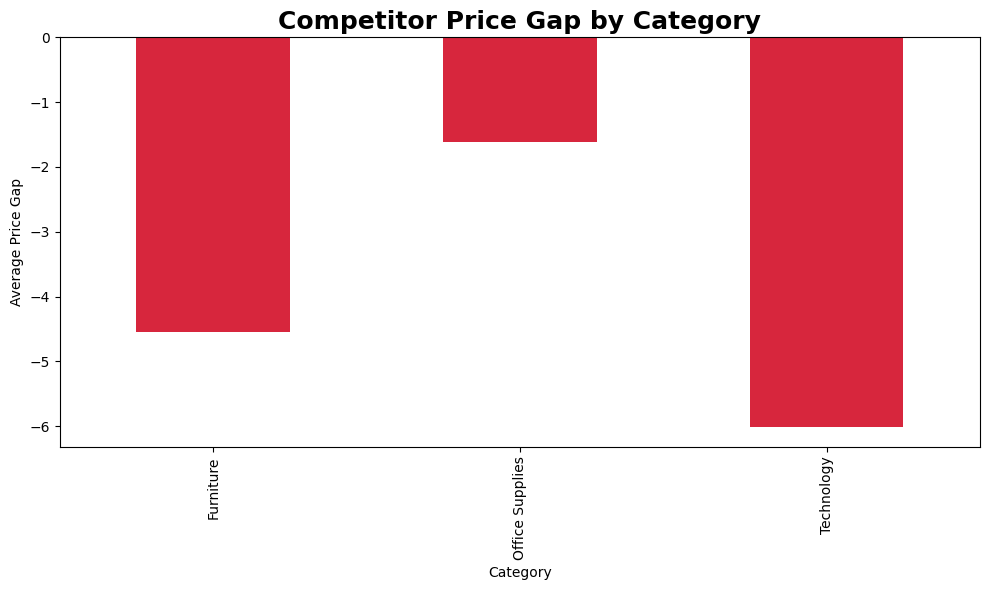

In [15]:
merged_df['price_gap'] = (
    merged_df['price'] -
    merged_df['competitor_price']
)
category_gap = (
    merged_df.groupby('category')['price_gap']
    .mean()
)
plt.figure(figsize=(10, 6))
category_gap.plot(
    kind='bar',
    color=DANGER_COLOR
)
plt.title(
    'Competitor Price Gap by Category',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Category')
plt.ylabel('Average Price Gap')
plt.tight_layout()
plt.savefig(
    '../visuals/charts/competitor_price_gap.png',
    dpi=300
)
plt.show()

### Revenue Contribution by Segment

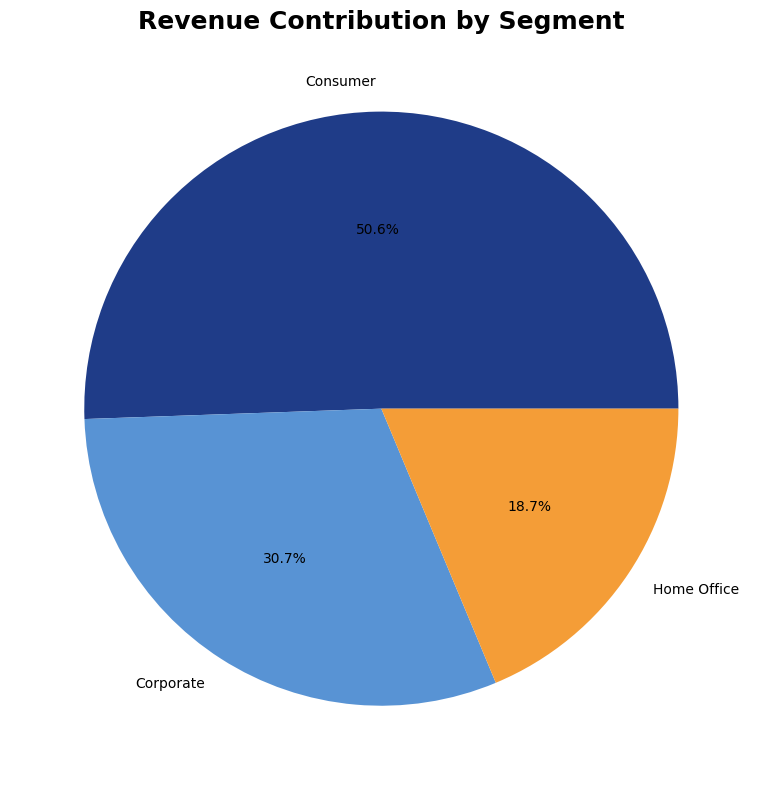

In [16]:
segment_revenue = (
    merged_df.groupby('segment')['revenue']
    .sum()
)
plt.figure(figsize=(8, 8))
segment_revenue.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[
        PRIMARY_COLOR,
        SECONDARY_COLOR,
        ACCENT_COLOR
    ]
)
plt.title(
    'Revenue Contribution by Segment',
    fontsize=18,
    fontweight='bold'
)
plt.ylabel('')
plt.tight_layout()
plt.savefig(
    '../visuals/charts/customer_segments.png',
    dpi=300
)
plt.show()